## Problem 2 Overview

This notebook completes the adapted VGGNet experiment for CIFAR-10. The code trains a reduced VGG-style model, tests dropout rates of p = 0.3 and p = 0.5, and compares the best VGG result with the modified AlexNet result from Problem 1.


### Mount Google Drive

This cell connects Google Drive to Colab so Problem 2 checkpoints, plots, and CSV files are saved persistently.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Imports, Reproducibility, and Output Folders

This cell imports the packages used for VGG training and evaluation. It also sets seed 42, chooses the GPU if available, and creates the Problem 2 output folders.


In [2]:
import os
import time
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset
from PIL import Image

seed = 42
batch_size = 128
learning_rate = 0.001
vgg_epochs = 30
num_classes = 10

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

OUTPUT_DIR = Path("/content/drive/MyDrive/ECGR4106_HW1/problem2")
FIG_DIR = OUTPUT_DIR / "figures"
CKPT_DIR = OUTPUT_DIR / "checkpoints"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", OUTPUT_DIR)

Using device: cuda
Saving outputs to: /content/drive/MyDrive/ECGR4106_HW1/problem2


### CIFAR-10 Dataset and DataLoaders

This cell uses the same CIFAR-10 preprocessing and fixed split as Problem 1. Matching the split and transforms makes the AlexNet-versus-VGG comparison fair.


In [3]:
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]


class CIFAR10FromArrays(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.fromarray(self.images[idx])
        label = int(self.labels[idx])
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def load_cifar10_from_fastai_mirror():
    import tarfile
    import urllib.request

    data_root = Path("./data")
    archive_path = data_root / "fastai-cifar10.tgz"
    extracted_root = data_root / "cifar10"
    url = "https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz"

    data_root.mkdir(parents=True, exist_ok=True)

    if not extracted_root.exists():
        print("Downloading CIFAR-10 from fast.ai mirror...")
        urllib.request.urlretrieve(url, archive_path)
        print("Extracting CIFAR-10 archive...")
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(data_root)

    train_dir = extracted_root / "train"
    test_dir = extracted_root / "test"

    train_base = torchvision.datasets.ImageFolder(train_dir, transform=train_transform)
    val_base = torchvision.datasets.ImageFolder(train_dir, transform=eval_transform)
    test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=eval_transform)

    print("Loaded CIFAR-10 with fast.ai mirror + PyTorch ImageFolder.")
    return train_base, val_base, test_dataset


def load_cifar10_datasets():
    try:
        print("Trying torchvision CIFAR-10 download...")
        train_base = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=train_transform)
        val_base = torchvision.datasets.CIFAR10("./data", train=True, download=False, transform=eval_transform)
        test_dataset = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=eval_transform)
        print("Loaded CIFAR-10 with torchvision.")
        return train_base, val_base, test_dataset
    except Exception as error:
        print("torchvision download failed:", repr(error))

    try:
        print("Trying tensorflow.keras CIFAR-10 loader...")
        import tensorflow as tf
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
        y_train = y_train.flatten()
        y_test = y_test.flatten()
        train_base = CIFAR10FromArrays(x_train, y_train, transform=train_transform)
        val_base = CIFAR10FromArrays(x_train, y_train, transform=eval_transform)
        test_dataset = CIFAR10FromArrays(x_test, y_test, transform=eval_transform)
        print("Loaded CIFAR-10 with tensorflow.keras arrays.")
        return train_base, val_base, test_dataset
    except Exception as error:
        print("tensorflow.keras download failed:", repr(error))

    print("Trying fast.ai public mirror...")
    return load_cifar10_from_fastai_mirror()


train_base, val_base, test_dataset = load_cifar10_datasets()

generator = torch.Generator().manual_seed(seed)
indices = torch.randperm(len(train_base), generator=generator).tolist()
train_indices = indices[:45000]
val_indices = indices[45000:]

train_dataset = Subset(train_base, train_indices)
val_dataset = Subset(val_base, val_indices)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=(device == "cuda"))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(device == "cuda"))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(device == "cuda"))

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Classes:", classes)

Trying torchvision CIFAR-10 download...
torchvision download failed: <HTTPError 403: 'Forbidden'>
Trying tensorflow.keras CIFAR-10 loader...
tensorflow.keras download failed: Exception('URL fetch failure on https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz: 403 -- Forbidden')
Trying fast.ai public mirror...
Extracting CIFAR-10 archive...


/tmp/ipykernel_1328/4064710455.py:55: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_root)


Loaded CIFAR-10 with fast.ai mirror + PyTorch ImageFolder.
Training images: 45000
Validation images: 5000
Test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Training and Plotting Helpers

This cell defines the reusable training, evaluation, checkpointing, plotting, and confusion matrix functions used for all VGG variants.


In [4]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, total_correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(1)
        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, total_correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model, run_name, epochs=30, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_val_acc = -1
    best_path = CKPT_DIR / f"{run_name}_best.pth"
    history = []
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
        epoch_time = time.time() - epoch_start

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": epoch_time,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)

        print(f"{run_name} | epoch {epoch:02d}/{epochs} | train loss {train_loss:.4f} | train acc {train_acc:.4f} | val loss {val_loss:.4f} | val acc {val_acc:.4f} | {epoch_time:.1f}s")

    total_time = time.time() - start_time
    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_DIR / f"{run_name}_history.csv", index=False)

    model.load_state_dict(torch.load(best_path, map_location=device))
    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

    summary = {
        "run_name": run_name,
        "epochs": epochs,
        "learning_rate": lr,
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "batch_size": batch_size,
        "seed": seed,
        "parameter_count": count_trainable_parameters(model),
        "best_val_accuracy": float(history_df["val_accuracy"].max()),
        "test_loss": float(test_loss),
        "final_test_accuracy": float(test_acc),
        "total_training_time_sec": float(total_time),
        "mean_epoch_time_sec": float(history_df["epoch_time_sec"].mean()),
    }

    with open(OUTPUT_DIR / f"{run_name}_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    return model, history_df, {"loss": test_loss, "accuracy": test_acc, "preds": test_preds, "labels": test_labels}, summary


def plot_history(history_df, run_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{run_name}: Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="Validation accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{run_name}: Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = FIG_DIR / f"{run_name}_curves.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)


def plot_confusion_matrix(labels, preds, run_name):
    matrix = np.zeros((len(classes), len(classes)), dtype=int)
    for true_label, pred_label in zip(labels, preds):
        matrix[true_label, pred_label] += 1

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_title(f"{run_name}: Confusion Matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)

    for i in range(len(classes)):
        for j in range(len(classes)):
            color = "white" if matrix[i, j] > matrix.max() * 0.55 else "black"
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center", color=color, fontsize=8)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    save_path = FIG_DIR / f"{run_name}_confusion_matrix.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)


def compare_histories(histories, metric, title, ylabel, filename):
    plt.figure(figsize=(8, 5))
    for run_name, history_df in histories.items():
        plt.plot(history_df["epoch"], history_df[metric], label=run_name)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_path = FIG_DIR / filename
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

### Adapted VGGNet Definition

This cell defines the reduced VGG-style model. It keeps the VGG idea of stacked 3x3 convolutions but reduces channel widths and classifier size so the parameter count stays near the modified AlexNet scale.


In [5]:
class AdaptedVGGNet(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.0):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 32 -> 16
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2: 16 -> 8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3: 8 -> 4
            nn.Conv2d(128, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(192, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 4: 4 -> 2
            nn.Conv2d(192, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 5: 2 -> 1
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        classifier = [
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
        ]
        if dropout_p > 0:
            classifier.append(nn.Dropout(p=dropout_p))
        classifier += [
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
        ]
        if dropout_p > 0:
            classifier.append(nn.Dropout(p=dropout_p))
        classifier.append(nn.Linear(256, num_classes))
        self.classifier = nn.Sequential(*classifier)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


test_model = AdaptedVGGNet(dropout_p=0.0)
vgg_params = count_trainable_parameters(test_model)
alexnet_problem1_params = 4_483_146

print(test_model)
print("Adapted VGG trainable parameters:", vgg_params)
print("Problem 1 Modified AlexNet trainable parameters:", alexnet_problem1_params)
print("Absolute parameter difference:", abs(vgg_params - alexnet_problem1_params))

AdaptedVGGNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(192, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

### Train VGG Baseline

This cell trains the adapted VGG model without dropout. The baseline provides the reference point for the dropout experiments.


In [6]:
vgg_baseline = AdaptedVGGNet(num_classes=num_classes, dropout_p=0.0)
vgg_baseline, hist_baseline, test_baseline, summary_baseline = train_model(
    vgg_baseline,
    run_name="vgg_baseline",
    epochs=vgg_epochs,
    lr=learning_rate,
)
summary_baseline

vgg_baseline | epoch 01/30 | train loss 1.9607 | train acc 0.2192 | val loss 1.7216 | val acc 0.3368 | 34.1s
vgg_baseline | epoch 02/30 | train loss 1.5731 | train acc 0.3949 | val loss 1.3961 | val acc 0.4784 | 32.0s
vgg_baseline | epoch 03/30 | train loss 1.3107 | train acc 0.5207 | val loss 1.1693 | val acc 0.5838 | 31.8s
vgg_baseline | epoch 04/30 | train loss 1.0881 | train acc 0.6122 | val loss 1.0554 | val acc 0.6314 | 37.7s
vgg_baseline | epoch 05/30 | train loss 0.9640 | train acc 0.6580 | val loss 0.9662 | val acc 0.6630 | 32.3s
vgg_baseline | epoch 06/30 | train loss 0.8656 | train acc 0.6960 | val loss 0.8945 | val acc 0.7060 | 32.0s
vgg_baseline | epoch 07/30 | train loss 0.7927 | train acc 0.7230 | val loss 0.7644 | val acc 0.7420 | 33.1s
vgg_baseline | epoch 08/30 | train loss 0.7419 | train acc 0.7448 | val loss 0.7937 | val acc 0.7344 | 32.2s
vgg_baseline | epoch 09/30 | train loss 0.6980 | train acc 0.7604 | val loss 0.7534 | val acc 0.7452 | 31.9s
vgg_baseline | epoc

{'run_name': 'vgg_baseline',
 'epochs': 30,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'scheduler': 'CosineAnnealingLR',
 'batch_size': 128,
 'seed': 42,
 'parameter_count': 3107338,
 'best_val_accuracy': 0.8384,
 'test_loss': 0.5266486712455749,
 'final_test_accuracy': 0.8343,
 'total_training_time_sec': 974.8937349319458,
 'mean_epoch_time_sec': 32.406041232744855}

### Plot VGG Baseline Results

This cell creates the training curves and confusion matrix for the VGG baseline.


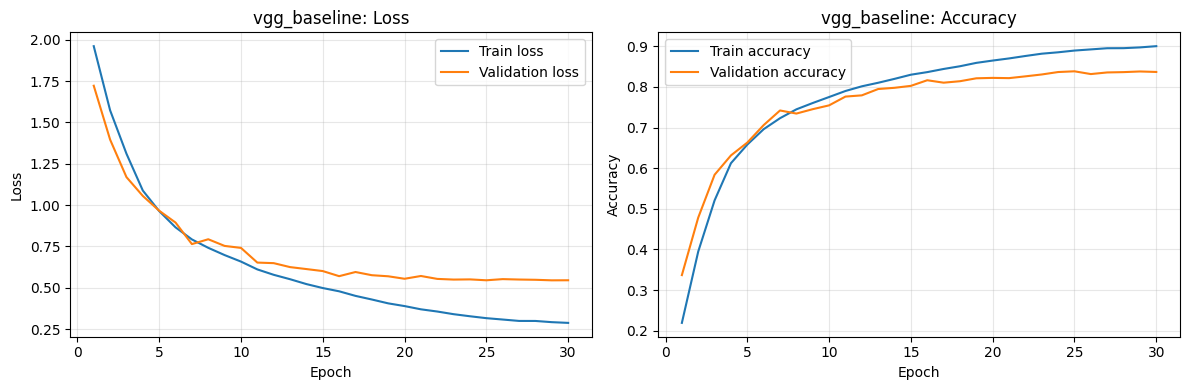

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem2/figures/vgg_baseline_curves.png


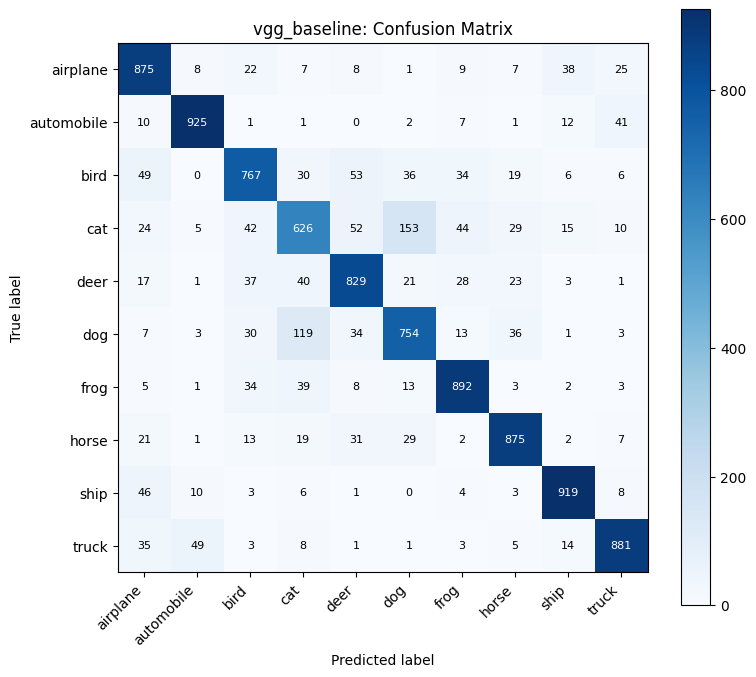

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem2/figures/vgg_baseline_confusion_matrix.png


In [7]:
plot_history(hist_baseline, "vgg_baseline")
plot_confusion_matrix(test_baseline["labels"], test_baseline["preds"], "vgg_baseline")

### Train VGG with Dropout p = 0.3

This cell trains the adapted VGG with dropout p = 0.3 in the classifier. This tests moderate regularization under the same hyperparameters as the baseline.


In [8]:
vgg_dropout_03 = AdaptedVGGNet(num_classes=num_classes, dropout_p=0.3)
vgg_dropout_03, hist_dropout_03, test_dropout_03, summary_dropout_03 = train_model(
    vgg_dropout_03,
    run_name="vgg_dropout_03",
    epochs=vgg_epochs,
    lr=learning_rate,
)
summary_dropout_03

vgg_dropout_03 | epoch 01/30 | train loss 1.9549 | train acc 0.2228 | val loss 1.7030 | val acc 0.3276 | 31.8s
vgg_dropout_03 | epoch 02/30 | train loss 1.5889 | train acc 0.3868 | val loss 1.4416 | val acc 0.4452 | 32.0s
vgg_dropout_03 | epoch 03/30 | train loss 1.3314 | train acc 0.5115 | val loss 1.1945 | val acc 0.5716 | 32.1s
vgg_dropout_03 | epoch 04/30 | train loss 1.1598 | train acc 0.5886 | val loss 1.0539 | val acc 0.6264 | 32.2s
vgg_dropout_03 | epoch 05/30 | train loss 1.0096 | train acc 0.6485 | val loss 0.9780 | val acc 0.6684 | 32.4s
vgg_dropout_03 | epoch 06/30 | train loss 0.8971 | train acc 0.6934 | val loss 0.8511 | val acc 0.7142 | 32.2s
vgg_dropout_03 | epoch 07/30 | train loss 0.8182 | train acc 0.7230 | val loss 0.7930 | val acc 0.7276 | 32.2s
vgg_dropout_03 | epoch 08/30 | train loss 0.7642 | train acc 0.7428 | val loss 0.8190 | val acc 0.7278 | 32.4s
vgg_dropout_03 | epoch 09/30 | train loss 0.7044 | train acc 0.7606 | val loss 0.7148 | val acc 0.7678 | 32.7s
v

{'run_name': 'vgg_dropout_03',
 'epochs': 30,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'scheduler': 'CosineAnnealingLR',
 'batch_size': 128,
 'seed': 42,
 'parameter_count': 3107338,
 'best_val_accuracy': 0.8462,
 'test_loss': 0.5359557279109954,
 'final_test_accuracy': 0.8424,
 'total_training_time_sec': 972.9385333061218,
 'mean_epoch_time_sec': 32.389767758051555}

### Plot VGG Dropout p = 0.3 Results

This cell creates the curves and confusion matrix for the VGG dropout p = 0.3 model.


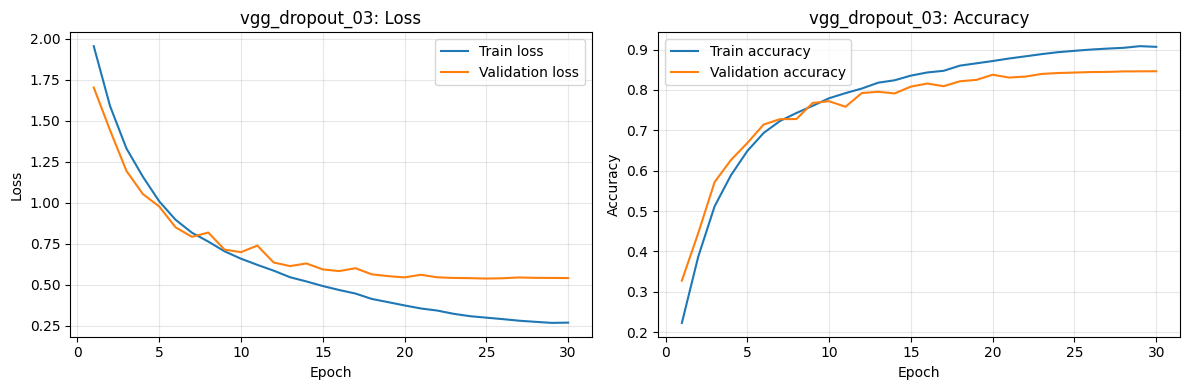

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem2/figures/vgg_dropout_03_curves.png


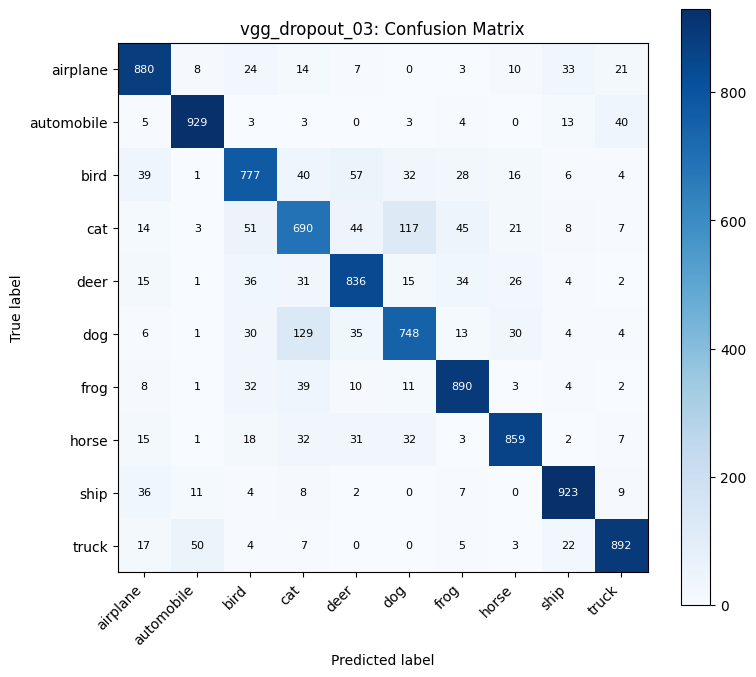

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem2/figures/vgg_dropout_03_confusion_matrix.png


In [9]:
plot_history(hist_dropout_03, "vgg_dropout_03")
plot_confusion_matrix(test_dropout_03["labels"], test_dropout_03["preds"], "vgg_dropout_03")

### Train VGG with Dropout p = 0.5

This cell trains the adapted VGG with stronger dropout p = 0.5. This checks whether heavier regularization helps or removes too much capacity.


In [10]:
vgg_dropout_05 = AdaptedVGGNet(num_classes=num_classes, dropout_p=0.5)
vgg_dropout_05, hist_dropout_05, test_dropout_05, summary_dropout_05 = train_model(
    vgg_dropout_05,
    run_name="vgg_dropout_05",
    epochs=vgg_epochs,
    lr=learning_rate,
)
summary_dropout_05

vgg_dropout_05 | epoch 01/30 | train loss 2.0032 | train acc 0.1954 | val loss 1.8465 | val acc 0.2750 | 32.8s
vgg_dropout_05 | epoch 02/30 | train loss 1.6671 | train acc 0.3527 | val loss 1.4937 | val acc 0.4178 | 32.1s
vgg_dropout_05 | epoch 03/30 | train loss 1.3950 | train acc 0.4825 | val loss 1.2009 | val acc 0.5698 | 32.5s
vgg_dropout_05 | epoch 04/30 | train loss 1.2209 | train acc 0.5700 | val loss 1.0739 | val acc 0.6136 | 32.3s
vgg_dropout_05 | epoch 05/30 | train loss 1.0726 | train acc 0.6264 | val loss 0.9704 | val acc 0.6706 | 32.4s
vgg_dropout_05 | epoch 06/30 | train loss 0.9661 | train acc 0.6692 | val loss 0.8647 | val acc 0.7010 | 32.4s
vgg_dropout_05 | epoch 07/30 | train loss 0.8897 | train acc 0.6983 | val loss 0.8508 | val acc 0.7148 | 32.2s
vgg_dropout_05 | epoch 08/30 | train loss 0.8248 | train acc 0.7223 | val loss 0.7771 | val acc 0.7322 | 32.4s
vgg_dropout_05 | epoch 09/30 | train loss 0.7757 | train acc 0.7410 | val loss 0.7324 | val acc 0.7548 | 32.6s
v

{'run_name': 'vgg_dropout_05',
 'epochs': 30,
 'learning_rate': 0.001,
 'optimizer': 'Adam',
 'scheduler': 'CosineAnnealingLR',
 'batch_size': 128,
 'seed': 42,
 'parameter_count': 3107338,
 'best_val_accuracy': 0.8258,
 'test_loss': 0.5326708211898804,
 'final_test_accuracy': 0.8322,
 'total_training_time_sec': 972.36900639534,
 'mean_epoch_time_sec': 32.37232394218445}

### Plot VGG Dropout p = 0.5 Results

This cell creates the curves and confusion matrix for the VGG dropout p = 0.5 model.


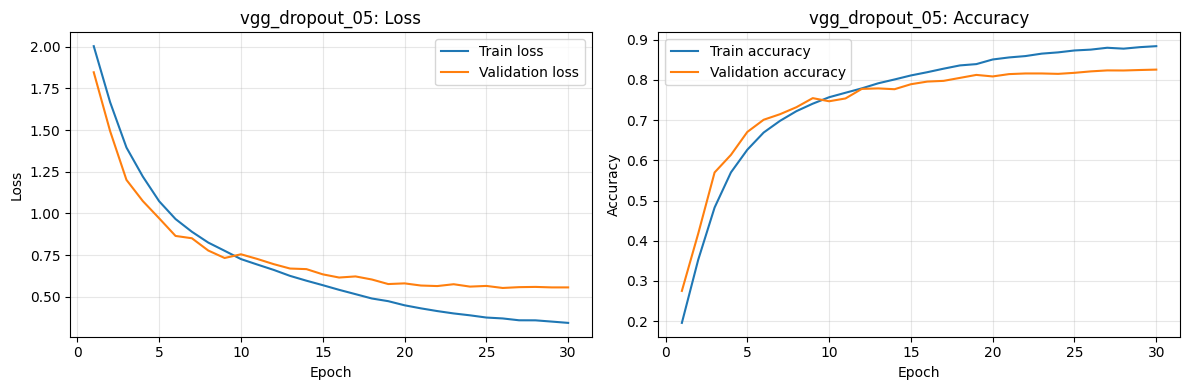

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem2/figures/vgg_dropout_05_curves.png


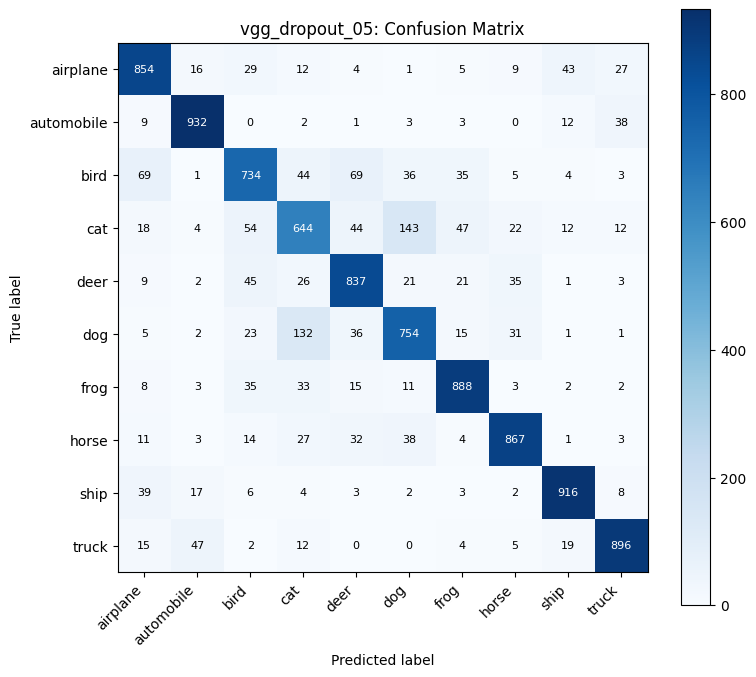

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem2/figures/vgg_dropout_05_confusion_matrix.png


In [11]:
plot_history(hist_dropout_05, "vgg_dropout_05")
plot_confusion_matrix(test_dropout_05["labels"], test_dropout_05["preds"], "vgg_dropout_05")

### Compare VGG Variants

This cell compares all VGG variants, saves the result table, and identifies the best VGG run by test accuracy.


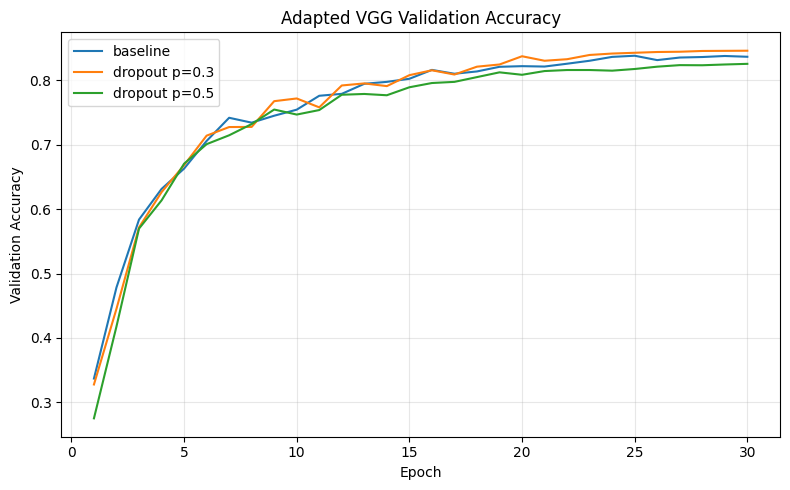

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem2/figures/vgg_val_accuracy_comparison.png


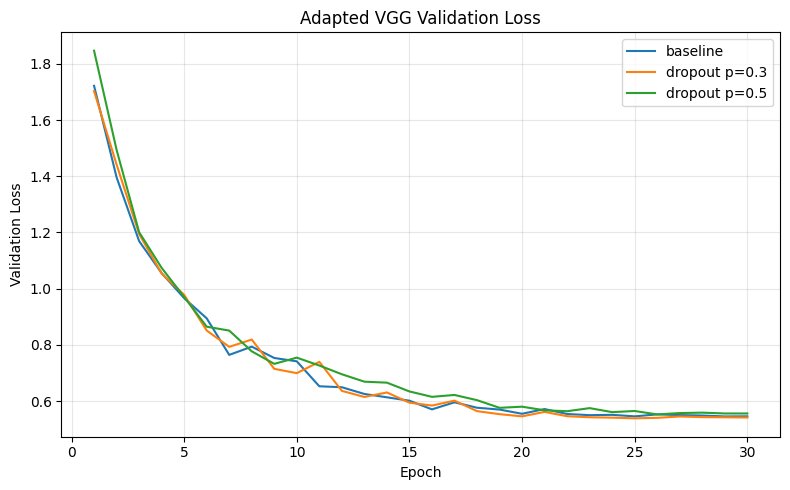

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem2/figures/vgg_val_loss_comparison.png


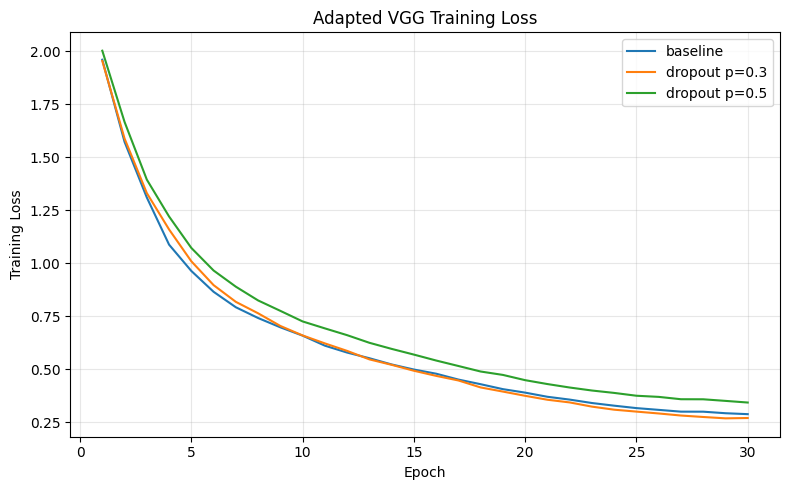

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem2/figures/vgg_train_loss_comparison.png


,run_name,dropout,parameter_count,best_val_accuracy,final_test_accuracy,mean_epoch_time_sec,total_training_time_sec,optimizer,learning_rate,scheduler,batch_size,seed
0,vgg_baseline,none,3107338,0.8384,0.8343,32.406041,974.893735,Adam,0.001,CosineAnnealingLR,128,42
1,vgg_dropout_03,0.3,3107338,0.8462,0.8424,32.389768,972.938533,Adam,0.001,CosineAnnealingLR,128,42
2,vgg_dropout_05,0.5,3107338,0.8258,0.8322,32.372324,972.369006,Adam,0.001,CosineAnnealingLR,128,42


In [12]:
histories = {
    "baseline": hist_baseline,
    "dropout p=0.3": hist_dropout_03,
    "dropout p=0.5": hist_dropout_05,
}

compare_histories(histories, "val_accuracy", "Adapted VGG Validation Accuracy", "Validation Accuracy", "vgg_val_accuracy_comparison.png")
compare_histories(histories, "val_loss", "Adapted VGG Validation Loss", "Validation Loss", "vgg_val_loss_comparison.png")
compare_histories(histories, "train_loss", "Adapted VGG Training Loss", "Training Loss", "vgg_train_loss_comparison.png")

results_df = pd.DataFrame([summary_baseline, summary_dropout_03, summary_dropout_05])
results_df["dropout"] = ["none", "0.3", "0.5"]
results_df = results_df[[
    "run_name",
    "dropout",
    "parameter_count",
    "best_val_accuracy",
    "final_test_accuracy",
    "mean_epoch_time_sec",
    "total_training_time_sec",
    "optimizer",
    "learning_rate",
    "scheduler",
    "batch_size",
    "seed",
]]
results_df.to_csv(OUTPUT_DIR / "problem2_vgg_results.csv", index=False)
results_df

### VGG Test Accuracy Bar Chart

This cell plots the final test accuracy for each VGG variant.


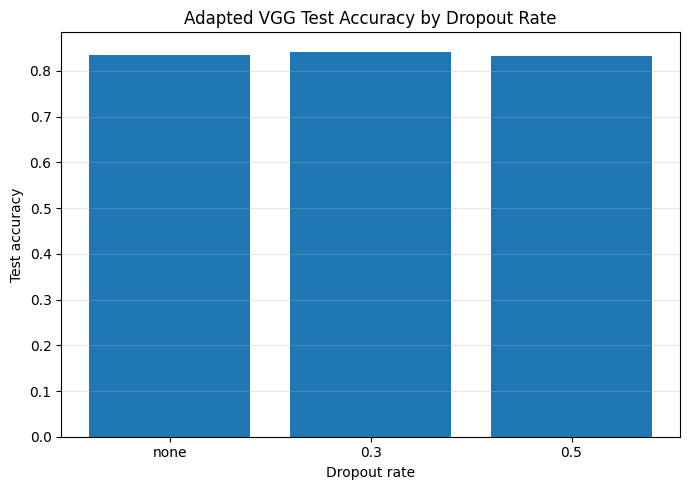

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem2/figures/vgg_test_accuracy_bar_chart.png


In [13]:
plt.figure(figsize=(7, 5))
plt.bar(results_df["dropout"], results_df["final_test_accuracy"])
plt.xlabel("Dropout rate")
plt.ylabel("Test accuracy")
plt.title("Adapted VGG Test Accuracy by Dropout Rate")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_path = FIG_DIR / "vgg_test_accuracy_bar_chart.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", save_path)

### Compare AlexNet and VGG

This cell creates the required cross-model comparison between the Problem 1 AlexNet result and the best Problem 2 VGG result.


In [14]:
alexnet_reference = {
    "model": "Modified AlexNet baseline",
    "dropout": "none",
    "parameter_count": 4_483_146,
    "best_val_accuracy": 0.8498,
    "final_test_accuracy": 0.8477,
    "mean_epoch_time_sec": 27.52,
}

best_vgg_idx = results_df["final_test_accuracy"].idxmax()
best_vgg = results_df.loc[best_vgg_idx]

comparison_df = pd.DataFrame([
    alexnet_reference,
    {
        "model": best_vgg["run_name"],
        "dropout": best_vgg["dropout"],
        "parameter_count": int(best_vgg["parameter_count"]),
        "best_val_accuracy": float(best_vgg["best_val_accuracy"]),
        "final_test_accuracy": float(best_vgg["final_test_accuracy"]),
        "mean_epoch_time_sec": float(best_vgg["mean_epoch_time_sec"]),
    }
])

comparison_df.to_csv(OUTPUT_DIR / "problem2_alexnet_vs_vgg_comparison.csv", index=False)
comparison_df

,model,dropout,parameter_count,best_val_accuracy,final_test_accuracy,mean_epoch_time_sec
0,Modified AlexNet baseline,none,4483146,0.8498,0.8477,27.520000
1,vgg_dropout_03,0.3,3107338,0.8462,0.8424,32.389768


### AlexNet versus VGG Bar Chart

This cell visualizes the test accuracy comparison between the modified AlexNet baseline and the best adapted VGG model.


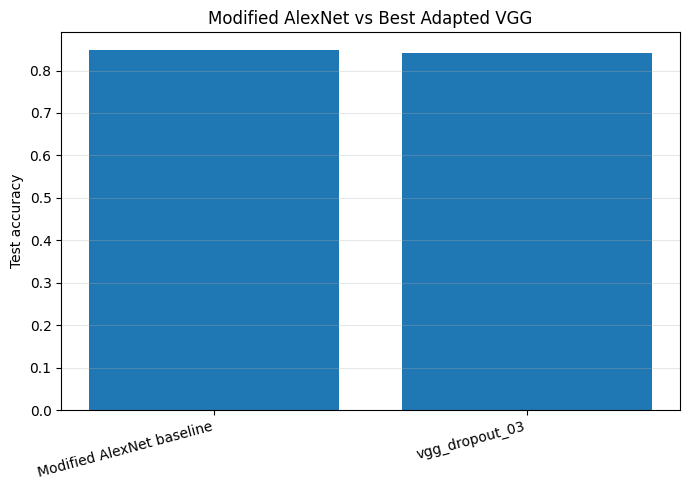

Saved: /content/drive/MyDrive/ECGR4106_HW1/problem2/figures/alexnet_vs_best_vgg_test_accuracy.png


In [15]:
plt.figure(figsize=(7, 5))
plt.bar(comparison_df["model"], comparison_df["final_test_accuracy"])
plt.ylabel("Test accuracy")
plt.title("Modified AlexNet vs Best Adapted VGG")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_path = FIG_DIR / "alexnet_vs_best_vgg_test_accuracy.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", save_path)